In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
lab2text = pd.read_csv("../processed/labels.csv")
lab2text.head()

,Unnamed: 0,0,1
0,0,Ё,0
1,1,А,1
2,2,Р,2
3,3,Е,3
4,4,Ч,4


In [3]:
df = pd.read_parquet("../processed/test.parquet")
df.head()

,features,label
0,"[[0.285888671875, 0.3349609375, 0.362060546875...",0
1,"[[0.257080078125, 0.2939453125, 0.320068359375...",1
2,"[[0.305908203125, 0.34912109375, 0.3740234375,...",2
3,"[[0.2548828125, 0.301025390625, 0.3330078125, ...",3
4,"[[0.240966796875, 0.2900390625, 0.333984375, 0...",4


In [15]:
test_set = df.loc[:5]
#test_set['features'].loc[0]

In [5]:
x = test_set['features'].loc[0][0][:42]
y = test_set['features'].loc[0][0][42:]

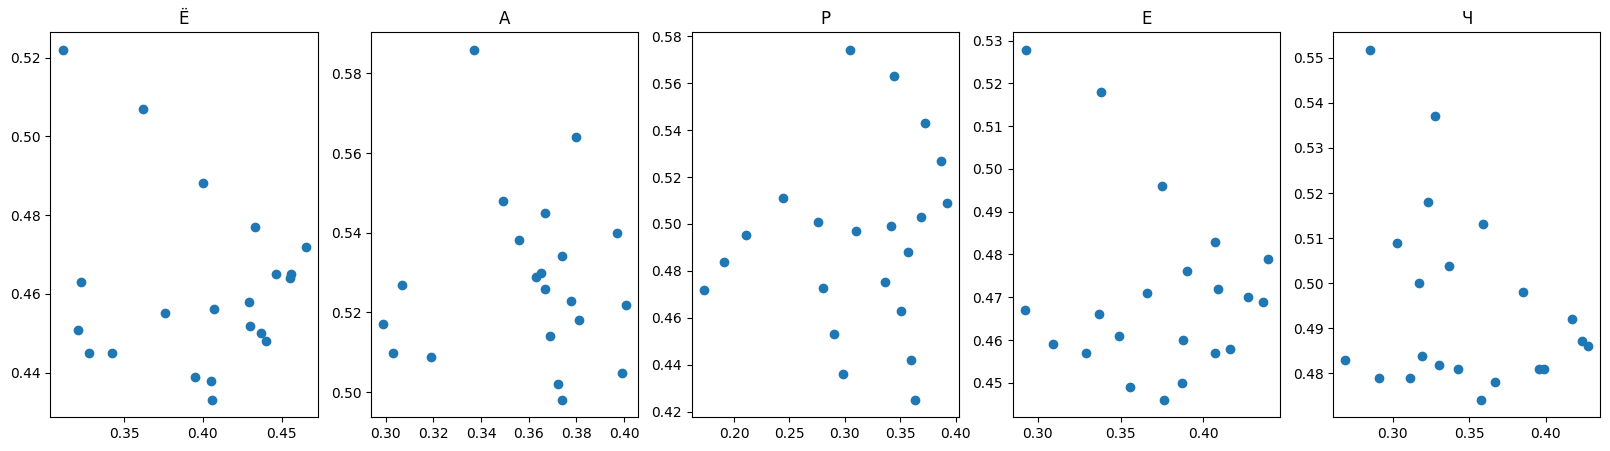

In [6]:
fig, axes = plt.subplots(1, 5)
fig.set_size_inches(20, 5)

frame = 20

for gesture_idx in range(5):
    x = test_set['features'].loc[gesture_idx][frame][:21]
    y = test_set['features'].loc[gesture_idx][frame][21:42]
    axes[gesture_idx].scatter(x, y)
    axes[gesture_idx].set_title(lab2text.loc[test_set['label'].loc[gesture_idx]]['0'])

In [8]:
import ijson
import numpy as np

def add_noise(gesture, mean, std):
    new_gesture = np.copy(gesture)
    for frame in new_gesture:
        noise = np.random.normal(mean, std, 84)
        frame += noise
    return new_gesture

def random_translate(gesture):
    new_gesture = np.copy(gesture)
    x_translate = np.random.rand()
    y_translate = np.random.rand()
    for frame in new_gesture:
        frame[:42] += x_translate
        frame[42:84] += y_translate
    return new_gesture

In [16]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
import numpy as np
import pandas as pd

def plot_mediapipe_hand_skeleton(ax, x_coords, y_coords, color):
    """Connect MediaPipe hand landmarks to form skeleton"""
    # MediaPipe hand connections (21 landmarks per hand)
    connections = [
        # Palm
        [0, 1, 2, 3, 4],           # Thumb
        [0, 5, 6, 7, 8],           # Index finger
        [0, 9, 10, 11, 12],        # Middle finger
        [0, 13, 14, 15, 16],       # Ring finger
        [0, 17, 18, 19, 20],       # Pinky
        # Palm connections
        [5, 9], [9, 13], [13, 17]
    ]
    
    for connection in connections:
        for i in range(len(connection) - 1):
            start_idx, end_idx = connection[i], connection[i + 1]
            if (start_idx < len(x_coords) and end_idx < len(x_coords) and
                not (np.isnan(x_coords[start_idx]) or np.isnan(x_coords[end_idx]))):
                ax.plot(
                    [x_coords[start_idx], x_coords[end_idx]],
                    [y_coords[start_idx], y_coords[end_idx]],
                    color=color, linewidth=2, alpha=0.7
                )

def animate_test_data_single(test_set, gesture_idx, lab2text, save_path=None):
    """Animate a single gesture from your test data"""

    gesture_landmarks = test_set['features'].loc[gesture_idx]
    gesture_name = lab2text.loc[test_set['label'].loc[gesture_idx]]['0']
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    def update(frame_idx):
        ax.clear()
        
        # Get frame data
        frame_data = gesture_landmarks[frame_idx]
        
        # Extract coordinates according to your structure
        hand1_x = frame_data[0:21]   # Hand 1 X coordinates
        hand1_y = frame_data[21:42]  # Hand 1 Y coordinates
        hand2_x = frame_data[42:63]  # Hand 2 X coordinates  
        hand2_y = frame_data[63:84]  # Hand 2 Y coordinates
        
        # Plot hand1 landmarks
        valid_hand1 = ~(np.isnan(hand1_x) | np.isnan(hand1_y))
        if np.any(valid_hand1):
            ax.scatter(hand1_x[valid_hand1], hand1_y[valid_hand1], 
                      c='red', s=50, label='Hand 1', alpha=0.7, marker='o')
            plot_mediapipe_hand_skeleton(ax, hand1_x, hand1_y, 'red')
        
        # Plot hand2 landmarks
        valid_hand2 = ~(np.isnan(hand2_x) | np.isnan(hand2_y))
        if np.any(valid_hand2):
            ax.scatter(hand2_x[valid_hand2], hand2_y[valid_hand2], 
                      c='blue', s=50, label='Hand 2', alpha=0.7, marker='o')
            plot_mediapipe_hand_skeleton(ax, hand2_x, hand2_y, 'blue')
        
        # Set plot properties
        ax.set_xlim(0, 1)  # MediaPipe coordinates are normalized [0, 1]
        ax.set_ylim(1, 0)  # Invert Y axis (image coordinates)
        ax.set_xlabel('X Coordinate')
        ax.set_ylabel('Y Coordinate')
        ax.set_title(f'Gesture: {gesture_name}\nFrame: {frame_idx+1}/{len(gesture_landmarks)}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
    
    # Create animation
    anim = FuncAnimation(
        fig, update, frames=len(gesture_landmarks), 
        interval=100, repeat=True
    )
    
    # Save if path provided
    if save_path:
        anim.save(save_path, writer='pillow', fps=10)
        print(f"✅ Animation saved: {save_path}")
    
    plt.tight_layout()
    return anim

✅ Animation saved: original.gif


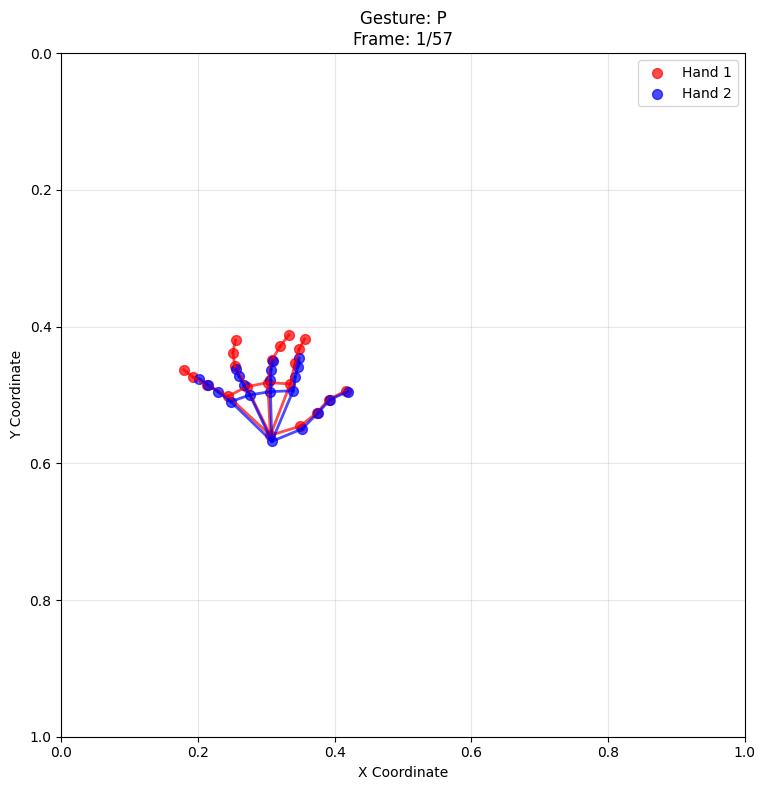

In [17]:
animate_test_data_single(test_set, 2, lab2text, save_path="original.gif")